# Alpha factory prototype
the financial type of alpha. Could have called it edge factory



In [6]:
%load_ext autoreload
%autoreload 2
from collections import deque
from alphaFactoryLib.kdb_interface import kdb_link as kdb

import pandas as pd
import random 
import numpy as np
import math 
import copy


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [7]:
ops = ["+", "-", "*", "/"]
DATA_WINDOW_LENGTH = 200



### indicators

In [8]:
# simple moving average
def SMA(data_window, lag_window=20, col="Close"):
    if len(data_window) < lag_window:
        return None
    window = [bar[col] for bar in data_window]
    return sum(window[-lag_window:]) / lag_window



# ADX is a momentum oscillator which can offer insights into whether an asset is trending and if so how significantly. 
# It quantifies price action, allowing traders to see whether a particular move falls within a trending or non-trending market
# aiding entry or exit decisions. 
# from: https://tabtrader.com/academy/articles/average-directional-index-adx-explained

# I love side effects
ADX_prior_smoothed_plus_dm = 0.0
ADX_prior_smoothed_minus_dm = 0.0
ADX_prior_ATR = 0.0
ADX_prior_ADX = 0.0
ADX_dx_history = [] 

# yea holy fuck i tried, but i just had gemini make it
"Avg Directional Index, Trend strength"
# Returns a value between 0 and 100, with higher values indicating a stronger trend. Either skyrocketing or plummeting. 
# 20 to 25: A trend is starting to break out or form.
# 25 to 50: A strong, established trend is underway.
# Over 50: An extremely strong, historic trend (often unsustainable over the long term).
def ADX(data_window, window=14):
    global ADX_prior_smoothed_plus_dm, ADX_prior_smoothed_minus_dm
    global ADX_prior_ATR, ADX_prior_ADX, ADX_dx_history

    if len(data_window) < 2:
        return None
    
    prev_bar = data_window[-2]
    last_bar = data_window[-1]

    # 1. Calculate Raw Directional Movement
    up_move = last_bar["High"] - prev_bar["High"]
    down_move = prev_bar["Low"] - last_bar["Low"]

    current_plus_dm = 0
    current_minus_dm = 0

    if up_move > down_move and up_move > 0:
        current_plus_dm = up_move
    elif down_move > up_move and down_move > 0:
        current_minus_dm = down_move

    # 2. Wilder's Smoothing for both DM tracks independently
    smoothed_plus_dm_today = ADX_prior_smoothed_plus_dm - (ADX_prior_smoothed_plus_dm / window) + current_plus_dm
    smoothed_minus_dm_today = ADX_prior_smoothed_minus_dm - (ADX_prior_smoothed_minus_dm / window) + current_minus_dm

    # 3. Calculate True Range and Smoothed ATR
    # Note: Using your key case lowercase 'close' from your original snippet
    true_range = max(
        last_bar["High"] - last_bar["Low"], 
        abs(last_bar["High"] - prev_bar["Close"]), 
        abs(last_bar["Low"] - prev_bar["Close"])
    )
    
    ATR_today = ADX_prior_ATR - (ADX_prior_ATR / window) + true_range

    # Guard against division by zero if ATR is completely flat
    if ATR_today == 0:
        return 0

    # 4. Calculate Directional Indicators (Fixed algebraic syntax matching your image)
    pos_DI = (smoothed_plus_dm_today / ATR_today) * 100
    neg_DI = (smoothed_minus_dm_today / ATR_today) * 100

    # 5. Calculate DX (Added absolute value to match image)
    dx_denom = pos_DI + neg_DI
    DX = (abs(pos_DI - neg_DI) / dx_denom * 100) if dx_denom != 0 else 0

    # 6. Smooth DX to get final ADX
    ADX_dx_history.append(DX)
    
    if len(ADX_dx_history) < window:
        # We don't have enough days yet to calculate an ADX baseline
        current_adx = 0 
    elif len(ADX_dx_history) == window:
        # First ADX point is a Simple Moving Average of the first 14 DX values
        current_adx = sum(ADX_dx_history) / window
    else:
        # Standard day-to-day rolling ADX formula
        current_adx = (ADX_prior_ADX * (window - 1) + DX) / window

    # 7. Update your global state variables for tomorrow's run
    ADX_prior_smoothed_plus_dm = smoothed_plus_dm_today
    ADX_prior_smoothed_minus_dm = smoothed_minus_dm_today
    ADX_prior_ATR = ATR_today
    ADX_prior_ADX = current_adx

    return current_adx







# RSI measures the speed and magnitude of a security's recent price changes
"relative strength index, The velocity of the price change and the magnitude of the price change"
# returns 0 to 100, with high values indicating overbought conditions and low values indicating oversold conditions
# 0 to 30: Oversold conditions, potential buying opportunity.
# 30 to 70: Neutral zone, no clear overbought or oversold conditions.
# 70 to 100: Overbought conditions, potential selling opportunity.
def RSI(data_window, window=14, col="Close"):
    if len(data_window) < 2:
        return None
    
    gains = []
    losses = []
    
    for i in range(1, min(len(data_window), window + 1)):
        change = data_window[-i][col] - data_window[-i - 1][col]
        if change > 0:
            gains.append(change)
            losses.append(0)
        else:
            gains.append(0)
            losses.append(-change)

    avg_gain = sum(gains) / window
    avg_loss = sum(losses) / window

    if avg_loss == 0:
        return 100  # Prevent division by zero; implies very strong upward momentum

    rs = avg_gain / avg_loss
    rsi = 100 - (100 / (1 + rs))
    
    return rsi


# measures the closing price of a security relative to its high-low range over a specific period
"stochastic oscillator, The position of the current close relative to the recent trading range"
# returns 0 to 100, with high values indicating overbought conditions and low values indicating oversold conditions
# Under 20: The asset is oversold, closing near the bottom of its recent range.
# 20 to 80: The asset is trading within its normal historical range.
# Over 80: The asset is overbought, closing near the top of its recent range.
def stochastic_oscillator(data_window, window=14, col="Close"):
    if len(data_window) < window:
        return None
    
    recent_window = list(data_window)[-window:]
    highest_high = max(bar["High"] for bar in recent_window)
    lowest_low = min(bar["Low"] for bar in recent_window)
    
    if highest_high == lowest_low:
        return 50  # Prevent division by zero; implies no price movement

    last_close = data_window[-1][col]
    k_percent = ((last_close - lowest_low) / (highest_high - lowest_low)) * 100
    
    return k_percent


# the point in which i gave up lol


# -------------------------------------------------------
# ATR - Average True Range
# -------------------------------------------------------
ATR_prior = 0.0

"Average True Range, Absolute volatility — how much is price actually moving?"
# Returns the average size of price moves over the window period, in price units.
# Small ATR: Low volatility, price is consolidating.
# Large ATR: High volatility, price is making big moves.
def ATR(data_window, window=14):
    global ATR_prior

    if len(data_window) < 2:
        return None

    prev_bar = data_window[-2]
    last_bar = data_window[-1]

    true_range = max(
        last_bar["High"] - last_bar["Low"],
        abs(last_bar["High"] - prev_bar["Close"]),
        abs(last_bar["Low"] - prev_bar["Close"])
    )

    # Wilder's smoothing (same method as ADX)
    if ATR_prior == 0.0:
        ATR_prior = true_range
        return ATR_prior

    ATR_today = ATR_prior - (ATR_prior / window) + true_range
    ATR_prior = ATR_today
    return ATR_today


# -------------------------------------------------------
# Bollinger Band Width
# -------------------------------------------------------
"Bollinger Band Width, Relative volatility — is the market squeezing or expanding?"
# Returns (upper - lower) / middle, i.e. band width as a fraction of price.
# Falling width (squeeze): Volatility is contracting, often precedes a big move.
# Rising width: Volatility is expanding, trend is accelerating.
def bollinger_band_width(data_window, window=20, num_std=2, col="Close"):
    if len(data_window) < window:
        return None

    closes = [bar[col] for bar in list(data_window)[-window:]]
    mean = sum(closes) / window
    variance = sum((c - mean) ** 2 for c in closes) / window
    std = variance ** 0.5

    upper = mean + num_std * std
    lower = mean - num_std * std

    if mean == 0:
        return None

    return (upper - lower) / mean


# -------------------------------------------------------
# OBV - On-Balance Volume
# -------------------------------------------------------
OBV_prior_value = 0.0
OBV_prior_close = None

"On-Balance Volume, Cumulative volume flow — are buyers or sellers in control?"
# Returns a running cumulative total (no fixed range).
# Rising OBV with rising price: Strong uptrend confirmed by volume.
# Falling OBV with rising price: Divergence — move may not be sustainable.
def OBV(data_window):
    global OBV_prior_value, OBV_prior_close

    if len(data_window) < 1:
        return None

    last_bar = data_window[-1]
    current_close = last_bar["Close"]
    current_volume = last_bar["Volume"]

    if OBV_prior_close is None:
        OBV_prior_close = current_close
        return OBV_prior_value

    if current_close > OBV_prior_close:
        OBV_prior_value += current_volume
    elif current_close < OBV_prior_close:
        OBV_prior_value -= current_volume
    # equal close: OBV unchanged

    OBV_prior_close = current_close
    return OBV_prior_value


# -------------------------------------------------------
# CMF - Chaikin Money Flow
# -------------------------------------------------------
"Chaikin Money Flow, Accumulation vs. distribution — who is winning over the window?"
# Returns a value between -1 and +1.
# Above 0: Accumulation (buying pressure dominant).
# Below 0: Distribution (selling pressure dominant).
# Above +0.25 or below -0.25: Strong signal.
def CMF(data_window, window=20):
    if len(data_window) < window:
        return None

    recent = list(data_window)[-window:]

    total_mfv = 0.0
    total_volume = 0.0

    for bar in recent:
        high = bar["High"]
        low = bar["Low"]
        close = bar["Close"]
        volume = bar["Volume"]

        price_range = high - low
        if price_range == 0:
            mfm = 0.0
        else:
            mfm = ((close - low) - (high - close)) / price_range

        total_mfv += mfm * volume
        total_volume += volume

    if total_volume == 0:
        return 0.0

    return total_mfv / total_volume


# -------------------------------------------------------
# Z-Score of Price
# -------------------------------------------------------
"Z-Score of Price, Mean reversion — how stretched is price from its average?"
# Returns standard deviations from the mean. No fixed range but typically -3 to +3.
# Above +2: Price is historically high relative to recent average, may revert down.
# Below -2: Price is historically low relative to recent average, may revert up.
# Near 0: Price is close to its recent mean.
def z_score(data_window, window=20, col="Close"):
    if len(data_window) < window:
        return None

    closes = [bar[col] for bar in list(data_window)[-window:]]
    mean = sum(closes) / window
    variance = sum((c - mean) ** 2 for c in closes) / window
    std = variance ** 0.5

    if std == 0:
        return 0.0

    return (closes[-1] - mean) / std


# -------------------------------------------------------
# Donchian Channel Position
# -------------------------------------------------------
"Donchian Channel Position, Range position — where is price within its recent high/low range?"
# Returns 0 to 1, where 0 = at the lowest low and 1 = at the highest high.
# Above 0.8: Price near top of range, potential breakout or overbought.
# Below 0.2: Price near bottom of range, potential breakdown or oversold.
# Near 0.5: Price in the middle of the range.
def donchian_channel_position(data_window, window=20, col="Close"):
    if len(data_window) < window:
        return None

    recent = list(data_window)[-window:]
    highest_high = max(bar["High"] for bar in recent)
    lowest_low = min(bar["Low"] for bar in recent)

    if highest_high == lowest_low:
        return 0.5  # No range movement

    current_close = data_window[-1][col]
    return (current_close - lowest_low) / (highest_high - lowest_low)


# tags are there so when GP is creating new indicators it wont add exact matches
functions = {
    1 : {"function" : SMA, "name" : "SMA", "categories": ["trend"], "type": "lagging"}, 
    2 : {"function" : ADX, "name" : "ADX", "categories": ["trend"], "type": "lagging"}, 
    3 : {"function" : RSI, "name" : "RSI", "categories": ["momentum"], "type": "leading"}, 
    4 : {"function" : stochastic_oscillator, "name" : "stochastic_oscillator", "categories": ["momentum"], "type": "leading"}, 
    5 : {"function" : ATR, "name" : "ATR", "categories": ["volatility"], "type": "coincident"}, 
    6 : {"function" : bollinger_band_width, "name" : "bollinger_band_width", "categories": ["volatility"], "type": "coincident"}, 
    7 : {"function" : OBV, "name" : "OBV", "categories": ["volume"], "type": "lagging"}, 
    8 : {"function" : CMF, "name" : "CMF", "categories": ["volume"], "type": "leading"}, 
    9 : {"function" : z_score, "name" : "z_score", "categories": ["statistical"], "type": "leading"}, 
    10 : {"function" : donchian_channel_position, "name" : "donchian_channel_position", "categories": ["trend"], "type": "coincident"}
}

function_categories = {
    SMA: {"categories": ["trend"], "type": "lagging"},
    ADX: {"categories": ["trend"], "type": "lagging"},  
    RSI: {"categories": ["momentum"], "type": "leading"},
    stochastic_oscillator: {"categories": ["momentum"], "type": "leading"},
    ATR: {"categories": ["volatility"], "type": "coincident"},
    bollinger_band_width: {"categories": ["volatility"], "type": "coincident"},
    OBV: {"categories": ["volume"], "type": "lagging"},
    CMF: {"categories": ["volume"], "type": "leading"},
    z_score: {"categories": ["statistical"], "type": "leading"},
    donchian_channel_position: {"categories": ["trend"], "type": "coincident"}  
}


In [9]:
params = {
         "script_path": "/home/mica/finProject/finStuff/databases/db_handler_alpha_fac.q", 
         "database_path": "/home/mica/finProject/finStuff/databases/db", 
         "start_date": "2020.01.01", 
         "end_date": "2020.12.31", 
         "ticker": "JPM",
         "timeframe": "1d"
         }



data_window = deque(maxlen=DATA_WINDOW_LENGTH)

jpm = kdb(params=params, chunk_size=100)
i = 0

dates = pd.date_range(start="2020-01-01", periods=1, freq="D")
data = pd.DataFrame(data={'price': 0, **{functions[key]["name"]: 0 for key in functions}}, index=dates)



#main loop for this
while True:
    i += 1
    df = jpm.read_chunk()

    if df is None:
        print(f"done after {i} chunks")
        break

    for i in range(len(df)):
        data_window.append(df.iloc[i])
        
        data = pd.concat([data, pd.DataFrame({
            "price": df.iloc[i]["Close"],
            **{functions[key]["name"]: functions[key]["function"](data_window) for key in functions}
        }, index=[df.index[i]])], ignore_index=False)

        for key in functions:
            func = functions[key]["function"]
            result = func(data_window)
            print(f"{func.__name__}: {result}")
        
data.to_csv("jpm_indicators_preprocessed.csv")
    


reading chunk
Querying kdb for data from 2020-01-01 00:00:00 to 2020-04-10 00:00:00
SMA: None
ADX: None
RSI: None
stochastic_oscillator: None
ATR: None
bollinger_band_width: None
OBV: 0.0
CMF: None
z_score: None
donchian_channel_position: None
SMA: None
ADX: 0
RSI: 0.0
stochastic_oscillator: None
ATR: 5.348751180532708
bollinger_band_width: None
OBV: -10386800.0
CMF: None
z_score: None
donchian_channel_position: None
SMA: None
ADX: 0
RSI: 0.0
stochastic_oscillator: None
ATR: 7.776620826512767
bollinger_band_width: None
OBV: -20645800.0
CMF: None
z_score: None
donchian_channel_position: None
SMA: None
ADX: 0
RSI: 0.0
stochastic_oscillator: None
ATR: 10.850209589126257
bollinger_band_width: None
OBV: -31177100.0
CMF: None
z_score: None
donchian_channel_position: None
SMA: None
ADX: 0
RSI: 19.73920247255495
stochastic_oscillator: None
ATR: 12.760903535914869
bollinger_band_width: None
OBV: -21481800.0
CMF: None
z_score: None
donchian_channel_position: None
SMA: None
ADX: 0
RSI: 26.5760336

In [10]:
class node:
    def __init__(self, data="", left=None, right=None):
        self.fitness = 0
        self.moves = 0  # Fixed: changed from local variable to instance attribute
        self.data = data
        self.left = left
        self.right = right

    def is_leaf(self):
        return self.left is None and self.right is None

    def __repr__(self):
        if self.is_leaf():
            return str(self.data)
        return f"({self.left} {self.data} {self.right})"

    def get_indicators(self):
        indicators = set()
        if self.is_leaf():
            # Matches against string names in your configuration
            if self.data in [functions[key]["name"] for key in functions]:
                indicators.add(self.data)
        else:
            indicators.update(self.left.get_indicators())
            indicators.update(self.right.get_indicators())
        return indicators

    def calculate(self, df_row):
        if self.is_leaf():
            return float(df_row[self.data])
 
        left_val = self.left.calculate(df_row)
        right_val = self.right.calculate(df_row)
 
        if self.data == "+":
            return left_val + right_val
        elif self.data == "-":
            return left_val - right_val
        elif self.data == "*":
            return left_val * right_val
        elif self.data == "/":
            if right_val == 0:
                return 0.0
            return left_val / right_val
 
        raise ValueError(f"Unknown operator: {self.data}")

    def set_fitness(self, fitness):
        self.fitness = fitness

    # --- NEW EVOLUTION FUNCTIONS ---

    def get_all_nodes(self):
        """
        Recursively collects references to all nodes in the tree.
        Used by crossover and mutation to pick random edit points.
        """
        nodes = [self]
        if not self.is_leaf():
            if self.left:
                nodes.extend(self.left.get_all_nodes())
            if self.right:
                nodes.extend(self.right.get_all_nodes())
        return nodes

    def copy(self):
        """
        Creates a deep copy of the tree structure.
        Prevents mutations to children from altering the parent histories.
        """
        new_node = node(data=self.data)
        new_node.fitness = self.fitness
        new_node.moves = self.moves
        if self.left:
            new_node.left = self.left.copy()
        if self.right:
            new_node.right = self.right.copy()
        return new_node

    def get_diversity_multiplier(self):
        """
        Uses your category strategy rule to penalize models that pack 
        redundant styles of technical indicators together.
        """
        used_indicators = self.get_indicators()
        
        if not used_indicators:
            return 0.0  # Formula is somehow empty or has zero TIs
            
        unique_categories = set()
        
        # Cross-reference the string name back to your category lists
        for ind_name in used_indicators:
            for key, meta in functions.items():
                if meta["name"] == ind_name:
                    unique_categories.update(meta["categories"])
                    break
                    
        num_categories = len(unique_categories)
        num_total_indicators = len(used_indicators)
        
        # Calculate C / Total ratio
        return float(num_categories / num_total_indicators)

In [11]:
def build_tree(current_depth, max_depth, method="grow"):
    if current_depth == max_depth:
        return node(data=random.choice(list(functions.values()))["name"])
    
    if method == "grow" and current_depth > 0:
        # 50% chance to terminate early and pick a leaf node
        if random.random() < 0.5:
            return node(data=random.choice(list(functions.values()))["name"])
        
    root = node(data=random.choice(ops))
    root.left = build_tree(current_depth + 1, max_depth, method)
    root.right = build_tree(current_depth + 1, max_depth, method)
    
    return root



In [12]:
SIGMOID_SCALING_FACTOR = 25

def simple_framework(program, data):
    result = program.calculate(data)

    if result > 0:
        return 1  # Buy signal
    elif result < 0:
        return -1  # Sell signal
    else:
        return 0  # Hold signal

def sigmoid_framework(program, data):
    try:
        result = program.calculate(data)
    except Exception as e:
        print(f"Error calculating program: {e}")
        return 0  # Default to hold on error

    result = result / SIGMOID_SCALING_FACTOR  # Scale down to prevent overflow in exp

    # for when we have way to big or small values from the program
    if result > 10:
        sigmoid_result = 1
    elif result < -10:
        sigmoid_result = 0
    else:
        sigmoid_result = 1 / (1 + math.exp(-result))
    
    if 0.45 <= sigmoid_result <= 0.55: # deadzone for doing nothing
        sigmoid_result = 0.5

    return sigmoid_result
    #if sigmoid_result > 0.6:
    #    return 1  # Buy signal
    #elif sigmoid_result < 0.4:
    #    return -1  # Sell signal
    #else:
    #    return 0  # Hold signal


def simple_signal_evaluator(signal):
    if signal == 1:
        return 1
    else:
        return 0
    
def tournament_selection(population, tournament_size=3):
    # Pick random candidates from the population
    candidates = random.sample(population, tournament_size)
    # The winner is the one with the highest fitness (e.g., -0.0005 beats -0.004)
    winner = max(candidates, key=lambda program: program.fitness)
    return winner


def crossover(parent_a, parent_b):
    # Deep copy the parents so we don't mutate the originals
    child_a = copy.deepcopy(parent_a)
    child_b = copy.deepcopy(parent_b)
    
    # 1. Get a list of all node references in both children
    nodes_a = child_a.get_all_nodes() # Internal method returning a list of pointers to nodes
    nodes_b = child_b.get_all_nodes()
    
    # 2. Pick a random crossover point in each tree
    target_node_a = random.choice(nodes_a)
    target_node_b = random.choice(nodes_b)
    
    # 3. Swap the sub-trees in place
    # Swap their functions, left children, and right children
    target_node_a.data, target_node_b.data = target_node_b.data, target_node_a.data
    target_node_a.left, target_node_b.left = target_node_b.left, target_node_a.left
    target_node_a.right, target_node_b.right = target_node_b.right, target_node_a.right
    
    return child_a, child_b

def generate_random_tree(max_depth, method="grow", current_depth=0):
    """
    Create a random subtree compatible with your `node` class.

    max_depth: remaining depth budget for this subtree
    method:
      - "full": force operator nodes until depth limit
      - "grow": allow early leaf termination
    """
    # Always stop at depth limit (or if caller gives negative depth)
    if max_depth <= 0:
        return node(data=random.choice(list(functions.values()))["name"])

    # In grow mode, optionally stop early with a leaf
    if method == "grow" and current_depth > 0 and random.random() < 0.5:
        return node(data=random.choice(list(functions.values()))["name"])

    # Otherwise create an operator node and recurse
    root = node(data=random.choice(ops))
    root.left = generate_random_tree(max_depth - 1, method=method, current_depth=current_depth + 1)
    root.right = generate_random_tree(max_depth - 1, method=method, current_depth=current_depth + 1)
    return root


def mutate(program, functions_dict, operators_list, max_depth=2):
    mutated_program = program.copy()
    nodes = mutated_program.get_all_nodes()
    target_node = random.choice(nodes)
    
    # Flip a coin: 50% change just the node value, 50% replace with a new random sub-tree
    if random.random() < 0.5:
        if target_node.is_leaf():
            # Change to a different random technical indicator ID
            target_node.data = random.choice([v["name"] for v in functions_dict.values()])
        else:
            # Change to a different math operator (+, -, *, /)
            target_node.data = random.choice(operators_list)
    else:
        # Generate a brand new random sub-tree and attach it here
        target_node.left = generate_random_tree(max_depth - 1)
        target_node.right = generate_random_tree(max_depth - 1)
        target_node.data = random.choice(operators_list)
        
    return mutated_program

## Processing Handler Boundary

This notebook currently splits into a few stable stages that should become handlers next:

1. Data acquisition and chunking: KDB / CSV loading into a raw frame.
2. Indicator preprocessing: window management, feature generation, and normalization.
3. Tree execution: program evaluation, signal shaping, and portfolio accounting.
4. Evolution control: population creation, selection, crossover, mutation, and ranking.
5. Diagnostics: OOS backtests, segmented decay checks, and max drawdown summaries.
6. Persistence: experiment logging and sequential result summaries.

The next extraction target is the processing layer that sits between raw data and the evolutionary search loop. That is the clean handoff point for the main processing handlers.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from alphaFactoryLib import prepare_dataset_from_csv

COMPLEXITY_LAMBDA = 3e-4

# --- Load and preprocess data via shared library helper ---
prepared_data = prepare_dataset_from_csv(
    "jpm_indicators_preprocessed.csv",
    price_col="price",
    train_fraction=0.7,
    clip_value=5.0,
)

df_raw = prepared_data.raw
train_raw = prepared_data.train_raw
test_raw = prepared_data.test_raw
train = prepared_data.train
test = prepared_data.test
feature_cols = prepared_data.feature_cols
price_col = prepared_data.price_col
mu = prepared_data.mu
sigma = prepared_data.sigma
split_idx = prepared_data.split_idx

print("Train rows:", len(train), "Test rows:", len(test))
print("Feature columns:", len(feature_cols))


# --- Tree complexity helper ---
def tree_size(n):
    if n is None:
        return 0
    if n.is_leaf():
        return 1
    return 1 + tree_size(n.left) + tree_size(n.right)


# --- Evaluate one program on one dataset ---
def evaluate_program(
    program,
    data,
    signal_fn,                    # e.g., sigmoid_framework
    cost_bps=5,                   # 5 bps transaction cost
    slippage_bps=2,               # 2 bps slippage
    complexity_lambda=1e-4        # penalty per node
):
    portfolio_value = 1000.0
    prev_portfolio = portfolio_value
    prev_price = float(data.iloc[0][price_col]) if len(data) > 0 else 0.0
    prev_row = None

    position = 0.0
    moves = 0
    returns = []

    for _, row in data.iterrows():
        price = float(row[price_col])

        # signal from previous row (prevents lookahead)
        if prev_row is None:
            signal = 0.0
        else:
            try:
                signal = float(signal_fn(program, prev_row))
            except Exception:
                signal = 0.0

        # clamp signal to [0,1]
        signal = max(0.0, min(1.0, signal))

        # trade sizing + costs
        trade_size = abs(signal - position)
        if trade_size > 1e-12:
            moves += 1

        total_trade_cost_rate = (cost_bps + slippage_bps) / 10000.0
        trade_cost = portfolio_value * trade_size * total_trade_cost_rate

        # apply PnL from held position as a fraction of portfolio
        if prev_price > 0:
            asset_return = (price / prev_price) - 1.0
        else:
            asset_return = 0.0
        step_pnl = portfolio_value * position * asset_return

        portfolio_value += step_pnl
        portfolio_value -= trade_cost

        if portfolio_value <= 0:
            returns.append(-1.0)
            break

        # log return
        if prev_portfolio > 0:
            r = np.log(portfolio_value / prev_portfolio)
        else:
            r = 0.0
        returns.append(r)

        # roll state
        prev_portfolio = portfolio_value
        prev_price = price
        prev_row = row
        position = signal

    returns = np.array(returns, dtype=float)
    if len(returns) == 0:
        raw_fitness = -1.0
    else:
        mu = np.mean(returns)
        sd = np.std(returns) + 1e-12
        sharpe = (mu / sd) * np.sqrt(252)
        eq = np.exp(np.cumsum(returns))
        peak = np.maximum.accumulate(eq)
        max_dd = np.max((peak - eq) / np.maximum(peak, 1e-12))
        ret_total = (portfolio_value / 1000.0) - 1.0
        raw_fitness = 0.6 * sharpe + 0.3 * ret_total - 0.4 * max_dd

    turnover = moves / max(1, len(returns))
    penalty = complexity_lambda * tree_size(program)
    fitness = raw_fitness - penalty - 0.15 * turnover

    return {
        "fitness": float(fitness),
        "raw_fitness": float(raw_fitness),
        "penalty": float(penalty),
        "moves": int(moves),
        "final_value": float(portfolio_value),
        "num_steps": int(len(returns)),
    }

Train rows: 1164 Test rows: 499
Feature columns: 10


In [14]:
FITNESS_CUTOFF = 0.3
INITIAL_POPULATION = 250
GENERATIONS = 25
MIN_DEPTH = 1
MAX_DEPTH = 4


programs = []
for i in range(INITIAL_POPULATION):
    depth = random.randint(MIN_DEPTH, MAX_DEPTH)
    method = "full" if i % 2 == 0 else "grow"
    programs.append(build_tree(current_depth=0, max_depth=depth, method=method))

print("Sample programs:")
for i in range(5):
    print(f"Program {i}: {programs[i]}")

Sample programs:
Program 0: ((ADX / bollinger_band_width) * (ADX * stochastic_oscillator))
Program 1: (bollinger_band_width * stochastic_oscillator)
Program 2: (ATR - OBV)
Program 3: (OBV * (z_score * OBV))
Program 4: (ATR / bollinger_band_width)


In [15]:
MUTATION_RATE = 0.45
TOURNAMENT_SIZE = 2

gen_history = []

for generation in range(GENERATIONS):
    # --- Evaluate population on TRAIN ---
    fitnesses = []
    move_counts = []
    expr_set = set()

    for program in programs:
        stats = evaluate_program(
            program,
            train,
            signal_fn=sigmoid_framework,
            cost_bps=5,
            slippage_bps=2,
            complexity_lambda=3e-4
        )
        program.set_fitness(stats["fitness"])
        program.moves = stats["moves"]

        fitnesses.append(program.fitness)
        move_counts.append(program.moves)
        expr_set.add(str(program))

    fitnesses_arr = np.array(fitnesses, dtype=float)

    # Save generation metrics
    gen_history.append({
        "generation": generation,
        "best_fitness": float(np.max(fitnesses_arr)),
        "median_fitness": float(np.median(fitnesses_arr)),
        "std_fitness": float(np.std(fitnesses_arr)),
        "mean_moves": float(np.mean(move_counts)),
        "unique_expr_ratio": float(len(expr_set) / len(programs))
    })

    IMMIGRANT_FRAC = 0.10
    n_imm = int(len(programs) * IMMIGRANT_FRAC)
    
    # Keep best programs, replace worst with fresh random trees
    programs_sorted = sorted(programs, key=lambda p: p.fitness, reverse=True)
    survivors = programs_sorted[:-n_imm]
    
    immigrants = []
    for _ in range(n_imm):
        d = random.randint(MIN_DEPTH, MAX_DEPTH)
        m = "full" if random.random() < 0.5 else "grow"
        immigrants.append(build_tree(current_depth=0, max_depth=d, method=m))
    
    programs = survivors + immigrants

    # --- Create next generation ---
    next_generation = []
    best_program = max(programs, key=lambda p: p.fitness)
    next_generation.append(copy.deepcopy(best_program))  # elitism

    while len(next_generation) < len(programs):
        p1 = tournament_selection(programs, tournament_size=TOURNAMENT_SIZE)
        p2 = tournament_selection(programs, tournament_size=TOURNAMENT_SIZE)

        c1, c2 = crossover(p1, p2)

        if random.random() < MUTATION_RATE:
            c1 = mutate(c1, functions, ops)
        if random.random() < MUTATION_RATE:
            c2 = mutate(c2, functions, ops)

        next_generation.append(c1)
        if len(next_generation) < len(programs):
            next_generation.append(c2)

    programs = next_generation

    # Quick progress print
    g = gen_history[-1]
    print(
        f"Gen {generation:02d} | "
        f"best={g['best_fitness']:.6f} "
        f"median={g['median_fitness']:.6f} "
        f"std={g['std_fitness']:.6f} "
        f"moves={g['mean_moves']:.1f} "
        f"div={g['unique_expr_ratio']:.2f}"
    )

history_df = pd.DataFrame(gen_history)
display(history_df.tail())

print("Best fitness seen:", history_df["best_fitness"].max())
print("Median last gen:", history_df["median_fitness"].iloc[-1])
print("Diversity last gen:", history_df["unique_expr_ratio"].iloc[-1])

Gen 00 | best=0.448563 median=-0.031535 std=0.180268 moves=153.3 div=0.96
Gen 01 | best=0.882382 median=-0.030475 std=0.161037 moves=169.2 div=0.92
Gen 02 | best=0.882382 median=-0.031075 std=0.190280 moves=178.2 div=0.92
Gen 03 | best=0.882382 median=-0.031075 std=0.194725 moves=214.1 div=0.96
Gen 04 | best=0.882382 median=-0.029875 std=0.196550 moves=244.1 div=0.88
Gen 05 | best=2.117624 median=-0.029875 std=0.264118 moves=264.4 div=0.93
Gen 06 | best=2.117624 median=-0.029275 std=0.261135 moves=242.8 div=0.95
Gen 07 | best=2.117624 median=-0.029875 std=0.221218 moves=246.6 div=0.96
Gen 08 | best=2.117624 median=-0.019041 std=0.287615 moves=268.9 div=0.98
Gen 09 | best=2.117624 median=-0.029619 std=0.304845 moves=312.9 div=0.98
Gen 10 | best=2.117624 median=-0.029275 std=0.307460 moves=307.6 div=0.97
Gen 11 | best=2.117624 median=-0.029275 std=0.286087 moves=332.0 div=0.98
Gen 12 | best=2.117624 median=-0.028747 std=0.262849 moves=324.3 div=0.97
Gen 13 | best=2.117624 median=-0.02472

,generation,best_fitness,median_fitness,std_fitness,mean_moves,unique_expr_ratio
20,20,2.117624,0.086793,0.396036,504.076,0.992
21,21,2.170833,0.097106,0.406377,536.332,0.996
22,22,2.866916,0.125056,0.483313,558.012,1.000
23,23,2.866916,0.123964,0.525940,585.436,0.996
24,24,2.866916,0.189595,0.524212,585.852,0.996


Best fitness seen: 2.8669159545168577
Median last gen: 0.18959496591999012
Diversity last gen: 0.996


In [16]:
# Best on TRAIN
best_program = max(programs, key=lambda p: p.fitness)

train_stats = evaluate_program(
    best_program, train, signal_fn=sigmoid_framework,
    cost_bps=5, slippage_bps=2, complexity_lambda=COMPLEXITY_LAMBDA
)
test_stats = evaluate_program(
    best_program, test, signal_fn=sigmoid_framework,
    cost_bps=5, slippage_bps=2, complexity_lambda=COMPLEXITY_LAMBDA
)

print("Best program expression:")
print(best_program)
print("\nTRAIN stats:", train_stats)
print("TEST stats :", test_stats)

overfit_gap = train_stats["fitness"] - test_stats["fitness"]
print(f"\nOverfit gap (train - test fitness): {overfit_gap:.6f}")

Best program expression:
((((bollinger_band_width * ((CMF + bollinger_band_width) / (((OBV + z_score) - (ADX + ((donchian_channel_position * (stochastic_oscillator + ((donchian_channel_position - OBV) + ADX))) + (ATR / donchian_channel_position)))) - CMF))) / (stochastic_oscillator * donchian_channel_position)) + ((ATR / donchian_channel_position) - bollinger_band_width)) / (((z_score / ATR) * (CMF + z_score)) * (z_score - donchian_channel_position)))

TRAIN stats: {'fitness': 2.8669159545168577, 'raw_fitness': 2.96576543905294, 'penalty': 0.0147, 'moves': 653, 'final_value': 8772.55136364845, 'num_steps': 1164}
TEST stats : {'fitness': 0.10259223022218941, 'raw_fitness': 0.18853471519212928, 'penalty': 0.0147, 'moves': 237, 'final_value': 1348.444270758668, 'num_steps': 499}

Overfit gap (train - test fitness): 2.764324


/tmp/ipykernel_981/1050711206.py:52: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


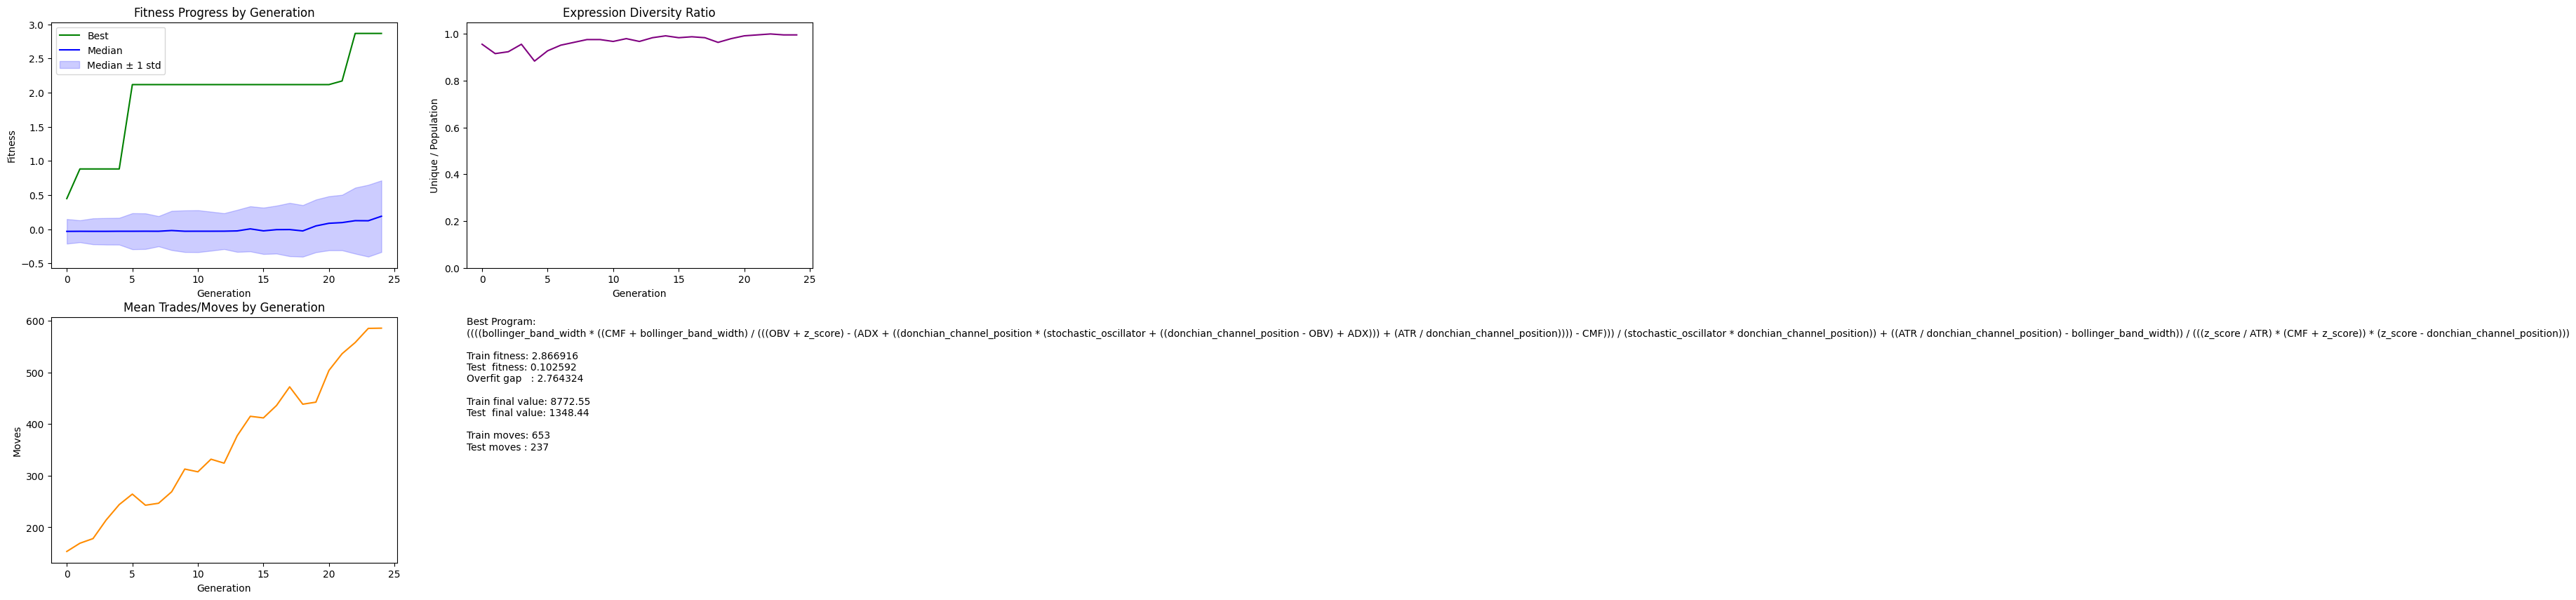

In [17]:
fig, axs = plt.subplots(2, 2, figsize=(14, 10))

# Fitness trajectory
axs[0, 0].plot(history_df["generation"], history_df["best_fitness"], label="Best", color="green")
axs[0, 0].plot(history_df["generation"], history_df["median_fitness"], label="Median", color="blue")
axs[0, 0].fill_between(
    history_df["generation"],
    history_df["median_fitness"] - history_df["std_fitness"],
    history_df["median_fitness"] + history_df["std_fitness"],
    alpha=0.2, color="blue", label="Median ± 1 std"
)
axs[0, 0].set_title("Fitness Progress by Generation")
axs[0, 0].set_xlabel("Generation")
axs[0, 0].set_ylabel("Fitness")
axs[0, 0].legend()

# Diversity
axs[0, 1].plot(history_df["generation"], history_df["unique_expr_ratio"], color="purple")
axs[0, 1].set_title("Expression Diversity Ratio")
axs[0, 1].set_xlabel("Generation")
axs[0, 1].set_ylabel("Unique / Population")
axs[0, 1].set_ylim(0, 1.05)

# Moves profile
axs[1, 0].plot(history_df["generation"], history_df["mean_moves"], color="darkorange")
axs[1, 0].set_title("Mean Trades/Moves by Generation")
axs[1, 0].set_xlabel("Generation")
axs[1, 0].set_ylabel("Moves")

# Train/Test summary
axs[1, 1].axis("off")
axs[1, 1].text(
    0.0, 1.0,
    "\n".join([
        f"Best Program:",
        f"{best_program}",
        "",
        f"Train fitness: {train_stats['fitness']:.6f}",
        f"Test  fitness: {test_stats['fitness']:.6f}",
        f"Overfit gap   : {train_stats['fitness'] - test_stats['fitness']:.6f}",
        "",
        f"Train final value: {train_stats['final_value']:.2f}",
        f"Test  final value: {test_stats['final_value']:.2f}",
        "",
        f"Train moves: {train_stats['moves']}",
        f"Test moves : {test_stats['moves']}",
    ]),
    va="top",
    fontsize=10
)

plt.tight_layout()
plt.show()

In [18]:
# Quick OOS backtest: evaluate top train performers on 2021 data
TOP_K = 10
OOS_PATH = "jpm_indicators_preprocessed_out_of_sample_2021.csv"

# 1) Re-evaluate current population on TRAIN so rankings are consistent
for p in programs:
    s = evaluate_program(
        p,
        train,
        signal_fn=sigmoid_framework,
        cost_bps=5,
        slippage_bps=2,
        complexity_lambda=COMPLEXITY_LAMBDA,
    )
    p.set_fitness(s["fitness"])

ranked = sorted(programs, key=lambda p: p.fitness, reverse=True)
top_programs = ranked[:TOP_K]

# 2) Load 2021 OOS data and preprocess with TRAIN mu/sigma (no leakage)
oos_raw = pd.read_csv(OOS_PATH)
if "Unnamed: 0" in oos_raw.columns:
    oos_raw = oos_raw.drop(columns=["Unnamed: 0"])

for c in oos_raw.columns:
    oos_raw[c] = pd.to_numeric(oos_raw[c], errors="coerce")

if price_col not in oos_raw.columns:
    raise ValueError(f"Expected '{price_col}' column in {OOS_PATH}")

missing_feats = [c for c in feature_cols if c not in oos_raw.columns]
if missing_feats:
    raise ValueError(f"Missing feature columns in OOS file: {missing_feats[:8]}")

oos = oos_raw.copy()
oos[feature_cols] = (oos_raw[feature_cols] - mu) / sigma
oos[feature_cols] = oos[feature_cols].clip(-5, 5)
oos = oos.fillna(0.0)

# 3) Backtest top programs on OOS 2021
rows = []
for rank, p in enumerate(top_programs, start=1):
    train_s = evaluate_program(
        p,
        train,
        signal_fn=sigmoid_framework,
        cost_bps=5,
        slippage_bps=2,
        complexity_lambda=COMPLEXITY_LAMBDA,
    )
    oos_s = evaluate_program(
        p,
        oos,
        signal_fn=sigmoid_framework,
        cost_bps=5,
        slippage_bps=2,
        complexity_lambda=COMPLEXITY_LAMBDA,
    )

    rows.append({
        "rank": rank,
        "train_fitness": train_s["fitness"],
        "oos_fitness_2021": oos_s["fitness"],
        "oos_raw_2021": oos_s["raw_fitness"],
        "oos_final_value_2021": oos_s["final_value"],
        "oos_moves_2021": oos_s["moves"],
        "program": str(p),
    })

results_2021 = pd.DataFrame(rows).sort_values("oos_fitness_2021", ascending=False)
display(results_2021)

print("Top 3 by OOS 2021 fitness:")
for _, r in results_2021.head(3).iterrows():
    print(
        f"#{int(r['rank'])} | oos_fit={r['oos_fitness_2021']:.6f} | "
        f"final={r['oos_final_value_2021']:.2f} | moves={int(r['oos_moves_2021'])}"
    )

,rank,train_fitness,oos_fitness_2021,oos_raw_2021,oos_final_value_2021,oos_moves_2021,program
5,6,1.573211,1.100166,1.250746,2827.968560,1345,(((RSI / (stochastic_oscillator * SMA)) + (((d...
8,9,1.277341,0.824582,0.984777,2415.602445,1472,(((RSI / (stochastic_oscillator * SMA)) + (((d...
9,10,1.163272,0.110411,0.255718,1568.252407,1293,((((z_score * (z_score / (((OBV - z_score) - (...
0,1,5.816289,-0.191593,-0.051510,1106.959254,1088,(((((ATR + z_score) + (CMF / (z_score * CMF)))...
3,4,1.991181,-0.388524,-0.247531,930.668167,1245,((((ATR * (((bollinger_band_width + ADX) - (((...
6,7,1.356743,-0.391213,-0.249469,898.583339,1240,((((z_score * ((z_score - OBV) / (((OBV - z_sc...
1,2,2.866916,-0.559321,-0.480900,667.887815,709,((((bollinger_band_width * ((CMF + bollinger_b...
4,5,1.794290,-0.585210,-0.494815,680.259280,909,((((ATR + z_score) + (CMF / (z_score * CMF))) ...
7,8,1.292458,-0.660550,-0.547800,606.994717,1111,((((bollinger_band_width * ((RSI - OBV) / (don...
2,3,2.376503,-0.686105,-0.541961,599.603715,1240,((((z_score * (((SMA + CMF) - OBV) / (((OBV - ...


Top 3 by OOS 2021 fitness:
#6 | oos_fit=1.100166 | final=2827.97 | moves=1345
#9 | oos_fit=0.824582 | final=2415.60 | moves=1472
#10 | oos_fit=0.110411 | final=1568.25 | moves=1293


## Why We Segment Train and OOS

This section checks whether a strategy is genuinely robust or just lucky in one regime.

### What "Robustness" Means Here

In this notebook, robustness is not a single universal metric from finance literature. It is a custom composite ranking designed to reward models that:

1. Perform reasonably on train.
2. Hold up on validation (inside train period, later in time).
3. Do not immediately fail in early OOS proxy windows.
4. Avoid excessive turnover/churn.

So the robust score is a practical selection tool for this pipeline, not a textbook constant.

### Why Segment the Data

A single full-period average can hide failure modes. Segmenting helps answer:

1. Does performance decay gradually?
2. Does it break right at regime change?
3. Are returns concentrated in a few lucky windows?

We split both train and OOS into equal chronological segments and evaluate top candidates in each segment.

### Key Metrics in This Section

- `last_train_segment_mean`: mean fitness in the final train segment.
- `first_oos_segment_mean`: mean fitness in the first OOS segment.
- `immediate_regime_gap = first_oos_segment_mean - last_train_segment_mean`.
- `overall_oos_decay = oos_mean_fitness_avg - train_mean_fitness_avg`.

Interpretation:

- Large negative `immediate_regime_gap`: regime-break behavior (fails quickly OOS).
- Negative `overall_oos_decay`: general degradation outside train.
- Near-zero or positive values: better stability (subject to costs/turnover realism).

### Why This Matters

The objective is not "max train score"; it is survivability under distribution shift.
A strategy with slightly lower train fitness but better segment stability is typically preferred for real deployment.

### Practical Next Steps After Reading Results

1. If immediate regime gap is strongly negative, tighten gates and/or reduce model complexity.
2. If decay is gradual, consider shorter retraining cadence.
3. Compare multiple selected programs by segment shape, not only by one final OOS number.

Segment summary across top train performers:


,sample,segment,label,mean_fitness,median_fitness,best_fitness,mean_final_value,mean_moves
0,oos2021,1,oos2021_1,0.554841,0.352042,1.913913,1123.636676,84.3
1,oos2021,2,oos2021_2,0.349202,0.175545,1.749267,1083.511294,96.1
2,oos2021,3,oos2021_3,0.604340,0.506724,1.589613,1123.768461,96.7
3,oos2021,4,oos2021_4,-0.482512,-0.548044,0.611751,968.032637,106.0
4,oos2021,5,oos2021_5,-0.565067,-0.592597,0.276021,959.879758,106.6
5,oos2021,6,oos2021_6,-0.475817,-0.379854,0.132486,969.115612,106.7
6,oos2021,7,oos2021_7,-0.002615,-0.526478,1.910924,997.285091,97.0
7,oos2021,8,oos2021_8,-0.034599,-0.425362,1.920469,992.369928,97.1
8,oos2021,9,oos2021_9,0.357939,0.103255,2.038742,1048.669039,95.3
9,oos2021,10,oos2021_10,-0.826185,-0.711558,-0.313445,907.764754,94.1



Detailed per-program segment results (head):


,sample,segment,label,rank,program,fitness,raw_fitness,final_value,moves,num_steps
0,train,1,train_1,1,(((((ATR + z_score) + (CMF / (z_score * CMF)))...,1.130556,1.256362,1599.977666,54,97
1,train,1,train_1,2,((((bollinger_band_width * ((CMF + bollinger_b...,0.992487,1.073682,1393.858749,43,97
2,train,1,train_1,3,((((z_score * (((SMA + CMF) - OBV) / (((OBV - ...,0.491011,0.636598,1248.819800,73,97
3,train,1,train_1,4,((((ATR * (((bollinger_band_width + ADX) - (((...,0.335234,0.438561,1184.378463,48,97
4,train,1,train_1,5,((((ATR + z_score) + (CMF / (z_score * CMF))) ...,0.648713,0.734733,1256.992256,50,97
5,train,1,train_1,6,(((RSI / (stochastic_oscillator * SMA)) + (((d...,0.406603,0.527540,1160.712158,59,97
6,train,1,train_1,7,((((z_score * ((z_score - OBV) / (((OBV - z_sc...,0.494039,0.631040,1247.184669,69,97
7,train,1,train_1,8,((((bollinger_band_width * ((RSI - OBV) / (don...,0.625677,0.720536,1262.658625,53,97
8,train,1,train_1,9,(((RSI / (stochastic_oscillator * SMA)) + (((d...,0.310349,0.427940,1141.507504,58,97
9,train,1,train_1,10,((((z_score * (z_score / (((OBV - z_score) - (...,0.805761,0.949294,1338.313549,74,97



Alpha decay summary:


,train_mean_fitness_avg,last_train_segment_mean,first_oos_segment_mean,immediate_regime_gap,oos_mean_fitness_avg,overall_oos_decay,library_segment_decay_pct
0,0.475709,-0.111905,0.554841,0.666746,-0.122038,-0.597748,-0.597748


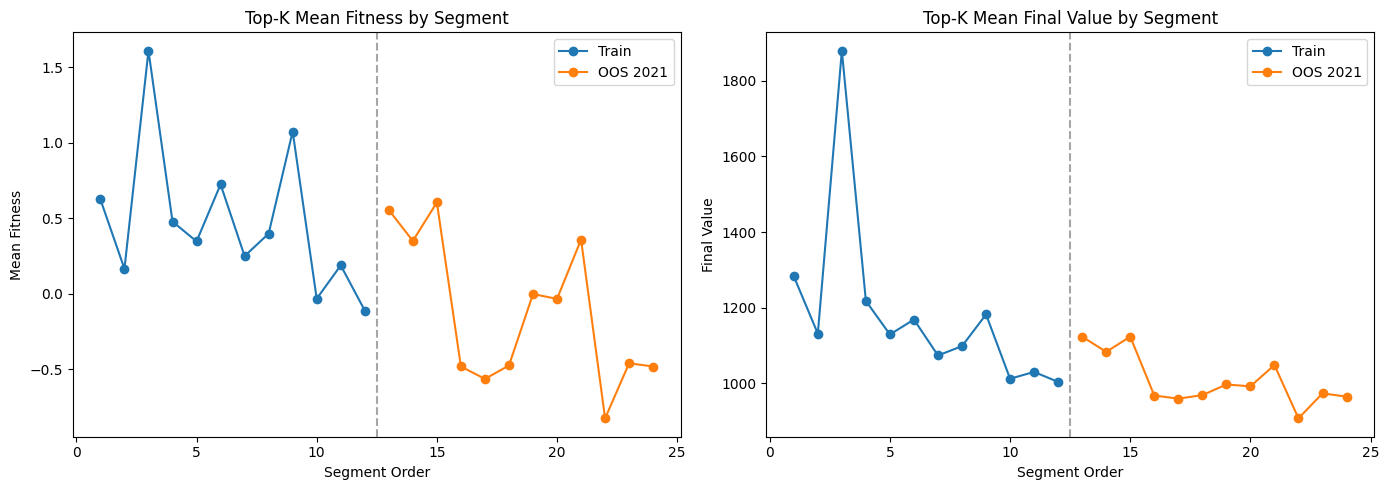

Decay exists, but it is more gradual: average OOS mean fitness is down -0.597748 vs train average.


In [ ]:
# Segment train and 2021 OOS to inspect alpha decay / regime sensitivity
from alphaFactoryLib import compute_decay_summary, normalize_external_frame, split_equal_segments

TRAIN_SEGMENTS = 12
OOS_SEGMENTS = 12
TOP_K_DECAY = 10
OOS_2021_PATH = "jpm_indicators_preprocessed_out_of_sample_2021.csv"


def load_and_preprocess_external(path):
    df_ext = pd.read_csv(path)
    return normalize_external_frame(
        df_ext,
        feature_cols=feature_cols,
        mu=mu,
        sigma=sigma,
        price_col=price_col,
        clip_value=5.0,
    )


def build_segments(df, n_segments, sample_name):
    segments = split_equal_segments(df, n_segments)
    out = []
    for i, seg in enumerate(segments, start=1):
        out.append(
            {
                "sample": sample_name,
                "segment": i,
                "label": f"{sample_name}_{i}",
                "start_row": int(seg.index[0]) if len(seg) > 0 else -1,
                "end_row": int(seg.index[-1]) if len(seg) > 0 else -1,
                "data": seg,
            }
        )
    return out


# Rank programs on full train first
for p in programs:
    train_full_stats = evaluate_program(
        p,
        train,
        signal_fn=sigmoid_framework,
        cost_bps=5,
        slippage_bps=2,
        complexity_lambda=COMPLEXITY_LAMBDA,
    )
    p.set_fitness(train_full_stats["fitness"])

ranked_programs = sorted(programs, key=lambda p: p.fitness, reverse=True)
decay_programs = ranked_programs[:TOP_K_DECAY]

# Load and segment datasets
train_segments = build_segments(train, TRAIN_SEGMENTS, "train")
oos_2021 = load_and_preprocess_external(OOS_2021_PATH)
oos_segments = build_segments(oos_2021, OOS_SEGMENTS, "oos2021")
all_segments = train_segments + oos_segments

# Score top programs on every segment
segment_rows = []
for seg in all_segments:
    for rank, p in enumerate(decay_programs, start=1):
        seg_stats = evaluate_program(
            p,
            seg["data"],
            signal_fn=sigmoid_framework,
            cost_bps=5,
            slippage_bps=2,
            complexity_lambda=COMPLEXITY_LAMBDA,
        )
        segment_rows.append(
            {
                "sample": seg["sample"],
                "segment": seg["segment"],
                "label": seg["label"],
                "rank": rank,
                "program": str(p),
                "fitness": seg_stats["fitness"],
                "raw_fitness": seg_stats["raw_fitness"],
                "final_value": seg_stats["final_value"],
                "moves": seg_stats["moves"],
                "num_steps": seg_stats["num_steps"],
            }
        )

segment_program_results = pd.DataFrame(segment_rows)

segment_summary = (
    segment_program_results.groupby(["sample", "segment", "label"], as_index=False)
    .agg(
        mean_fitness=("fitness", "mean"),
        median_fitness=("fitness", "median"),
        best_fitness=("fitness", "max"),
        mean_final_value=("final_value", "mean"),
        mean_moves=("moves", "mean"),
    )
)

train_summary = segment_summary[segment_summary["sample"] == "train"].copy()
oos_summary = segment_summary[segment_summary["sample"] == "oos2021"].copy()

last_train_mean = train_summary["mean_fitness"].iloc[-1]
first_oos_mean = oos_summary["mean_fitness"].iloc[0]
immediate_regime_gap = first_oos_mean - last_train_mean

train_avg = train_summary["mean_fitness"].mean()
oos_avg = oos_summary["mean_fitness"].mean()
overall_oos_decay = oos_avg - train_avg

decay_metrics = compute_decay_summary(
    train_summary["mean_fitness"].tolist(),
    oos_summary["mean_fitness"].tolist(),
)

alpha_decay_summary = pd.DataFrame(
    [
        {
            "train_mean_fitness_avg": train_avg,
            "last_train_segment_mean": last_train_mean,
            "first_oos_segment_mean": first_oos_mean,
            "immediate_regime_gap": immediate_regime_gap,
            "oos_mean_fitness_avg": oos_avg,
            "overall_oos_decay": overall_oos_decay,
            "library_segment_decay_pct": decay_metrics["segment_decay_pct"],
        }
    ]
)

print("Segment summary across top train performers:")
display(segment_summary)

print("\nDetailed per-program segment results (head):")
display(segment_program_results.head(20))

print("\nAlpha decay summary:")
display(alpha_decay_summary)

fig, axs = plt.subplots(1, 2, figsize=(14, 5))

axs[0].plot(train_summary["segment"], train_summary["mean_fitness"], marker="o", label="Train")
axs[0].plot(oos_summary["segment"] + TRAIN_SEGMENTS, oos_summary["mean_fitness"], marker="o", label="OOS 2021")
axs[0].axvline(TRAIN_SEGMENTS + 0.5, color="gray", linestyle="--", alpha=0.7)
axs[0].set_title("Top-K Mean Fitness by Segment")
axs[0].set_xlabel("Segment Order")
axs[0].set_ylabel("Mean Fitness")
axs[0].legend()

axs[1].plot(train_summary["segment"], train_summary["mean_final_value"], marker="o", label="Train")
axs[1].plot(oos_summary["segment"] + TRAIN_SEGMENTS, oos_summary["mean_final_value"], marker="o", label="OOS 2021")
axs[1].axvline(TRAIN_SEGMENTS + 0.5, color="gray", linestyle="--", alpha=0.7)
axs[1].set_title("Top-K Mean Final Value by Segment")
axs[1].set_xlabel("Segment Order")
axs[1].set_ylabel("Final Value")
axs[1].legend()

plt.tight_layout()
plt.show()

if immediate_regime_gap < -0.05:
    print(
        f"Immediate regime break detected: first OOS segment mean fitness dropped {immediate_regime_gap:.6f} vs last train segment."
    )
elif overall_oos_decay < -0.05:
    print(f"Decay exists, but it is more gradual: average OOS mean fitness is down {overall_oos_decay:.6f} vs train average.")
else:
    print("No major alpha decay detected under this segmentation.")

Inner-train rows: 931 | Validation rows: 233
OOS proxy A rows: 139 | OOS proxy B rows: 139
ROB Gen 000 | best_rob=0.074046 best_val=0.855058 valid=0.53 moves=140.5 div=0.97 pat=10
ROB Gen 001 | best_rob=0.157655 best_val=0.557655 valid=0.70 moves=95.0 div=0.93 pat=10
ROB Gen 002 | best_rob=0.258065 best_val=0.772021 valid=0.75 moves=83.4 div=0.84 pat=10
ROB Gen 003 | best_rob=0.258065 best_val=0.772021 valid=0.80 moves=71.6 div=0.80 pat=9
ROB Gen 004 | best_rob=0.258065 best_val=0.852374 valid=0.79 moves=60.4 div=0.69 pat=8
ROB Gen 005 | best_rob=0.258065 best_val=0.772021 valid=0.84 moves=47.9 div=0.67 pat=7
ROB Gen 006 | best_rob=0.258065 best_val=0.855155 valid=0.81 moves=53.4 div=0.65 pat=6
ROB Gen 007 | best_rob=0.258065 best_val=0.772021 valid=0.81 moves=59.1 div=0.64 pat=5
ROB Gen 008 | best_rob=0.258065 best_val=0.772021 valid=0.81 moves=61.4 div=0.60 pat=4
ROB Gen 009 | best_rob=0.258065 best_val=0.772021 valid=0.82 moves=48.7 div=0.55 pat=3
ROB Gen 010 | best_rob=0.381018 bes

,program,expr,robust_fitness,val_fitness,train_fitness,oos_proxy_a_fitness,oos_proxy_b_fitness,passes_gate,generation
0,(ADX / (RSI + (RSI / bollinger_band_width))),(ADX / (RSI + (RSI / bollinger_band_width))),0.381018,0.172400,-0.053899,2.094573,1.911504,True,10
1,(((stochastic_oscillator / donchian_channel_po...,(((stochastic_oscillator / donchian_channel_po...,0.377806,0.166854,0.058553,2.136425,1.838537,True,19
2,((stochastic_oscillator / RSI) * (ATR + OBV)),((stochastic_oscillator / RSI) * (ATR + OBV)),0.354942,0.195280,0.000985,1.722167,1.960806,True,16
3,((stochastic_oscillator / RSI) * (stochastic_o...,((stochastic_oscillator / RSI) * (stochastic_o...,0.350985,0.099943,-0.092443,2.300767,2.218226,True,15
4,(((stochastic_oscillator + OBV) - (stochastic_...,(((stochastic_oscillator + OBV) - (stochastic_...,0.349278,0.628962,0.622485,-0.122825,-0.295664,True,17
5,(((stochastic_oscillator + OBV) - (stochastic_...,(((stochastic_oscillator + OBV) - (stochastic_...,0.293796,0.593484,0.562142,-0.205319,-0.386490,True,16
6,((RSI - ADX) - (((bollinger_band_width / SMA) ...,((RSI - ADX) - (((bollinger_band_width / SMA) ...,0.278987,0.705078,-0.006106,0.244610,0.085430,True,11
7,(((stochastic_oscillator + ATR) - (stochastic_...,(((stochastic_oscillator + ATR) - (stochastic_...,0.274634,0.826415,-0.155240,0.238542,0.090007,True,18
8,((stochastic_oscillator / RSI) * (stochastic_o...,((stochastic_oscillator / RSI) * (stochastic_o...,0.264462,0.109143,-0.031302,1.714662,1.506581,True,12
9,((RSI - ADX) - (((z_score / SMA) / (RSI - boll...,((RSI - ADX) - (((z_score / SMA) / (RSI - boll...,0.258065,0.772021,-0.125419,0.248568,0.089407,True,2


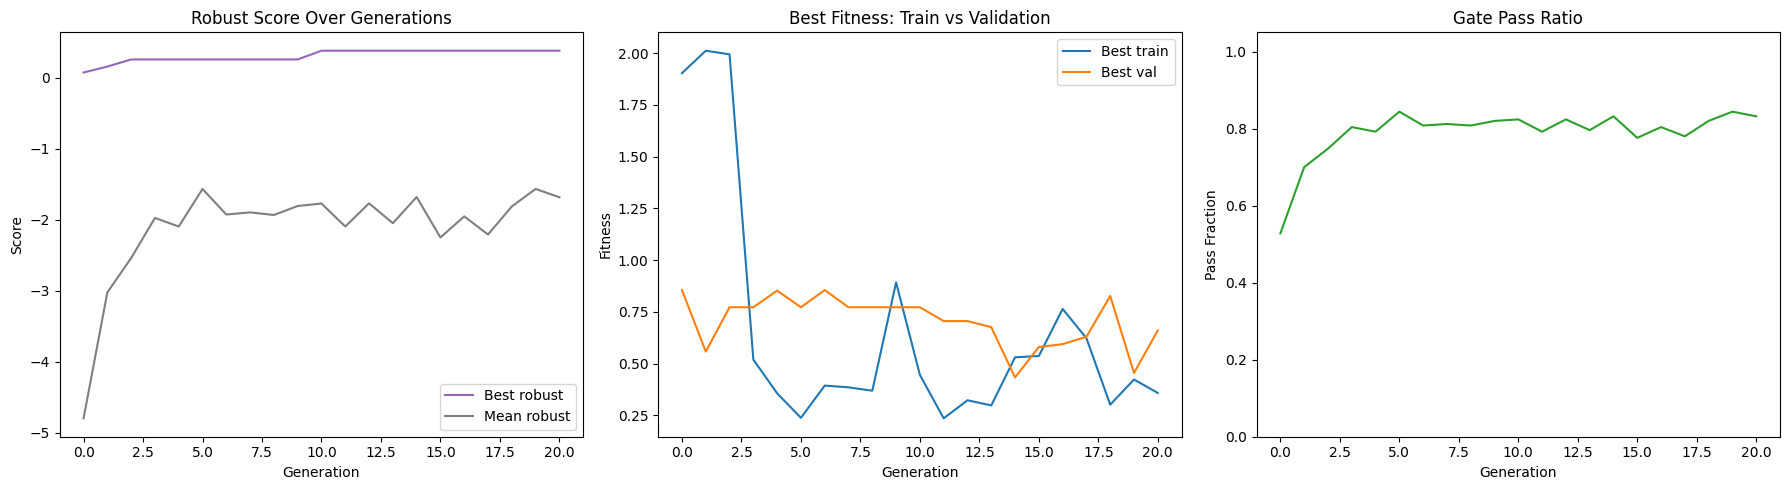

In [ ]:
# Early-stopped evolution with robustness gates (anti-overfit + anti-churn)
# Uses time-ordered split of train into inner_train + validation.

from alphaFactoryLib import (
    BACKTEST_COST_BPS,
    BACKTEST_SLIPPAGE_BPS,
    DEFAULT_HARD_GATES,
    DEFAULT_ROBUST_WEIGHTS,
    normalize_external_frame,
    run_robust_evolution,
)

VAL_FRACTION = 0.20
ES_GENERATIONS = GENERATIONS
ES_PATIENCE = 10
HOF_SIZE = 20

# Keep explicit values for notebook readability (same as defaults)
W_TRAIN = 0.35
W_VAL = 0.45
W_OOS_PROXY_A = 0.10
W_OOS_PROXY_B = 0.10

MIN_FINAL_VALUE = 1000.0
MAX_TURNOVER_RATIO = 0.65
EXTRA_TURNOVER_PENALTY = 0.08

split_val_idx = int(len(train) * (1.0 - VAL_FRACTION))
inner_train = train.iloc[:split_val_idx].copy()
val_seg = train.iloc[split_val_idx:].copy()

print(f"Inner-train rows: {len(inner_train)} | Validation rows: {len(val_seg)}")

# OOS proxy windows: first and second segments of 2021 to discourage immediate regime-break models
if "oos_2021" not in globals():
    oos_2021_raw = pd.read_csv("jpm_indicators_preprocessed_out_of_sample_2021.csv")
    oos_2021 = normalize_external_frame(
        oos_2021_raw,
        feature_cols=feature_cols,
        mu=mu,
        sigma=sigma,
        price_col=price_col,
        clip_value=5.0,
    )

oos_proxy_len = max(50, len(oos_2021) // 12)
oos_proxy_a = oos_2021.iloc[:oos_proxy_len].copy()
oos_proxy_b = oos_2021.iloc[oos_proxy_len:2 * oos_proxy_len].copy()
if len(oos_proxy_b) == 0:
    oos_proxy_b = oos_proxy_a.copy()

print(f"OOS proxy A rows: {len(oos_proxy_a)} | OOS proxy B rows: {len(oos_proxy_b)}")

# Fresh population for this robust experiment
es_programs = []
for i in range(INITIAL_POPULATION):
    d = random.randint(MIN_DEPTH, MAX_DEPTH)
    m = "full" if i % 2 == 0 else "grow"
    es_programs.append(build_tree(current_depth=0, max_depth=d, method=m))

weights = DEFAULT_ROBUST_WEIGHTS
hard_gates = DEFAULT_HARD_GATES

robust_result = run_robust_evolution(
    programs=es_programs,
    evaluate_program_fn=evaluate_program,
    signal_fn=sigmoid_framework,
    train_df=train,
    test_df=test,
    oos_df=oos_2021,
    inner_train_df=inner_train,
    validation_df=val_seg,
    oos_proxy_a_df=oos_proxy_a,
    oos_proxy_b_df=oos_proxy_b,
    tournament_selection_fn=tournament_selection,
    crossover_fn=crossover,
    mutate_fn=mutate,
    build_tree_fn=build_tree,
    functions_dict=functions,
    operators_list=ops,
    mutation_rate=MUTATION_RATE,
    tournament_size=TOURNAMENT_SIZE,
    immigrant_frac=IMMIGRANT_FRAC,
    min_depth=MIN_DEPTH,
    max_depth=MAX_DEPTH,
    generations=ES_GENERATIONS,
    patience=ES_PATIENCE,
    hall_of_fame_size=HOF_SIZE,
    complexity_lambda=COMPLEXITY_LAMBDA,
    cost_bps=BACKTEST_COST_BPS,
    slippage_bps=BACKTEST_SLIPPAGE_BPS,
    weights=weights,
    gates=hard_gates,
    extra_turnover_penalty=EXTRA_TURNOVER_PENALTY,
    verbose=True,
)

best_program_es = robust_result["best_program"]
best_gen = robust_result["best_generation"]
best_robust_seen = robust_result["best_robust_score"]
es_history_df = robust_result["es_history_df"]
hall_of_fame = robust_result["hall_of_fame"]

# Final chosen model from robust validation-driven evolution
selected_program = best_program_es
selected_train_stats = robust_result["selected_train_stats"]
selected_test_stats = robust_result["selected_test_stats"]
selected_oos_2021_stats = robust_result["selected_oos_stats"]

print("\nSelected robust program:")
print(selected_program)
print("\nSelected TRAIN stats:", selected_train_stats)
print("Selected TEST stats :", selected_test_stats)
print("Selected OOS 2021 stats:", selected_oos_2021_stats)
print("\nBest robust generation:", best_gen)
print("Best robust score:", best_robust_seen)

hof_df = pd.DataFrame(hall_of_fame)
print("\nHall-of-fame unique expressions (top 10):")
display(hof_df.head(10))

fig, axs = plt.subplots(1, 3, figsize=(18, 5))
axs[0].plot(es_history_df["generation"], es_history_df["best_robust"], label="Best robust", color="tab:purple")
axs[0].plot(es_history_df["generation"], es_history_df["mean_robust"], label="Mean robust", color="tab:gray")
axs[0].set_title("Robust Score Over Generations")
axs[0].set_xlabel("Generation")
axs[0].set_ylabel("Score")
axs[0].legend()

axs[1].plot(es_history_df["generation"], es_history_df["best_train"], label="Best train", color="tab:blue")
axs[1].plot(es_history_df["generation"], es_history_df["best_val"], label="Best val", color="tab:orange")
axs[1].set_title("Best Fitness: Train vs Validation")
axs[1].set_xlabel("Generation")
axs[1].set_ylabel("Fitness")
axs[1].legend()

axs[2].plot(es_history_df["generation"], es_history_df["valid_ratio"], color="tab:green")
axs[2].set_title("Gate Pass Ratio")
axs[2].set_xlabel("Generation")
axs[2].set_ylabel("Pass Fraction")
axs[2].set_ylim(0.0, 1.05)

plt.tight_layout()
plt.show()

,sample,segment,start,end,ret_pct,max_drawdown_pct
0,train,1,1000.0,1037.483942,3.748394,24.130627
1,train,2,1000.0,815.151864,-18.484814,23.845854
2,train,3,1000.0,1338.828824,33.882882,24.470067
3,train,4,1000.0,967.511242,-3.248876,23.818910
4,train,5,1000.0,958.294299,-4.170570,15.576934
5,train,6,1000.0,1040.568691,4.056869,14.134696
6,train,7,1000.0,969.208787,-3.079121,14.134696
7,train,8,1000.0,987.024666,-1.297533,11.771180
8,train,9,1000.0,1083.754983,8.375498,9.641991
9,train,10,1000.0,1032.854257,3.285426,5.100986


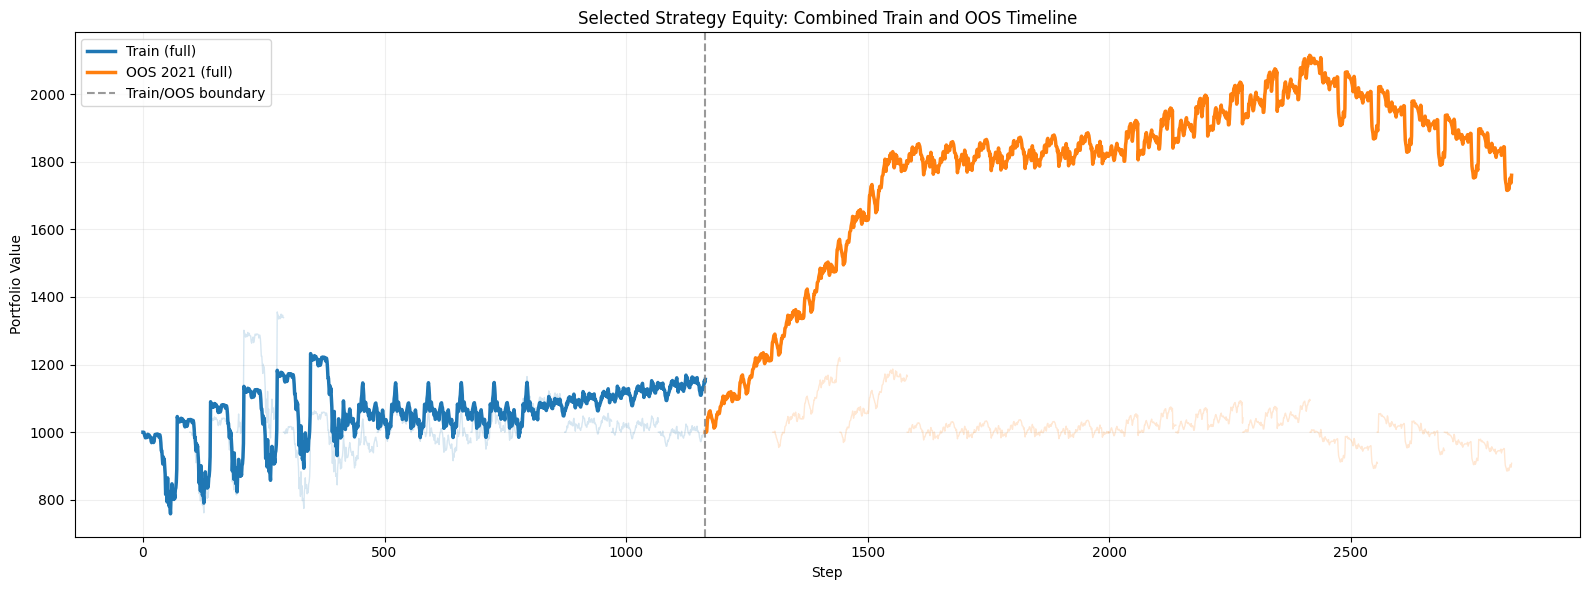

Mean train segment return %: 2.283
Mean OOS 2021 segment return %: 4.757
Segment return decay (OOS - train): 2.474
Mean train segment max drawdown %: 14.736
Mean OOS segment max drawdown %: 6.828


In [21]:
# Per-segment equity curves for selected robust program

def equity_curve_for_program(
    program,
    data,
    signal_fn,
    cost_bps=5,
    slippage_bps=2,
):
    portfolio_value = 1000.0
    prev_price = float(data.iloc[0][price_col]) if len(data) > 0 else 0.0
    prev_row = None
    position = 0.0

    curve = [portfolio_value]
    for _, row in data.iterrows():
        price = float(row[price_col])

        if prev_row is None:
            signal = 0.0
        else:
            try:
                signal = float(signal_fn(program, prev_row))
            except Exception:
                signal = 0.0

        signal = max(0.0, min(1.0, signal))

        trade_size = abs(signal - position)
        total_trade_cost_rate = (cost_bps + slippage_bps) / 10000.0
        trade_cost = portfolio_value * trade_size * total_trade_cost_rate

        if prev_price > 0:
            asset_return = (price / prev_price) - 1.0
        else:
            asset_return = 0.0

        step_pnl = portfolio_value * position * asset_return
        portfolio_value = portfolio_value + step_pnl - trade_cost
        portfolio_value = max(portfolio_value, 0.0)

        curve.append(portfolio_value)

        prev_price = price
        prev_row = row
        position = signal

    return np.array(curve, dtype=float)


def max_drawdown_pct(equity_curve):
    if len(equity_curve) == 0:
        return np.nan
    peak = np.maximum.accumulate(equity_curve)
    dd = (peak - equity_curve) / np.maximum(peak, 1e-12)
    return float(np.max(dd) * 100.0)


def split_df_segments(df, n_segments):
    idx_splits = np.array_split(np.arange(len(df)), n_segments)
    out = []
    for i, idxs in enumerate(idx_splits, start=1):
        if len(idxs) == 0:
            continue
        out.append((i, df.iloc[idxs].copy()))
    return out


if "selected_program" not in globals():
    raise RuntimeError("Run the robust selection cell first to create selected_program.")

train_seg_curves = split_df_segments(train, 12)
oos_seg_curves = split_df_segments(oos_2021, 12)

train_seg_summary = []
for seg_i, seg_df in train_seg_curves:
    c = equity_curve_for_program(selected_program, seg_df, sigmoid_framework)
    train_seg_summary.append({
        "sample": "train",
        "segment": seg_i,
        "start": float(c[0]),
        "end": float(c[-1]),
        "ret_pct": float((c[-1] / c[0] - 1.0) * 100.0) if c[0] > 0 else np.nan,
        "max_drawdown_pct": max_drawdown_pct(c),
    })

oos_seg_summary = []
for seg_i, seg_df in oos_seg_curves:
    c = equity_curve_for_program(selected_program, seg_df, sigmoid_framework)
    oos_seg_summary.append({
        "sample": "oos2021",
        "segment": seg_i,
        "start": float(c[0]),
        "end": float(c[-1]),
        "ret_pct": float((c[-1] / c[0] - 1.0) * 100.0) if c[0] > 0 else np.nan,
        "max_drawdown_pct": max_drawdown_pct(c),
    })

seg_equity_df = pd.DataFrame(train_seg_summary + oos_seg_summary)
display(seg_equity_df)

# Combined train -> OOS view for the same selected strategy
train_full_curve = equity_curve_for_program(selected_program, train, sigmoid_framework)
oos_full_curve = equity_curve_for_program(selected_program, oos_2021, sigmoid_framework)

x_train = np.arange(len(train_full_curve))
x_oos = np.arange(len(oos_full_curve)) + len(train_full_curve) - 1

fig, ax = plt.subplots(figsize=(16, 6))

# Light per-segment traces so you can see segment dispersion in one panel
offset = 0
for _, seg_df in train_seg_curves:
    c = equity_curve_for_program(selected_program, seg_df, sigmoid_framework)
    x = np.arange(len(c)) + offset
    ax.plot(x, c, color="tab:blue", alpha=0.18, linewidth=1)
    offset += max(1, len(c) - 1)

for _, seg_df in oos_seg_curves:
    c = equity_curve_for_program(selected_program, seg_df, sigmoid_framework)
    x = np.arange(len(c)) + offset
    ax.plot(x, c, color="tab:orange", alpha=0.18, linewidth=1)
    offset += max(1, len(c) - 1)

# Main full-dataset curves
ax.plot(x_train, train_full_curve, color="tab:blue", linewidth=2.5, label="Train (full)")
ax.plot(x_oos, oos_full_curve, color="tab:orange", linewidth=2.5, label="OOS 2021 (full)")

split_x = len(train_full_curve) - 1
ax.axvline(split_x, color="gray", linestyle="--", alpha=0.8, label="Train/OOS boundary")
ax.set_title("Selected Strategy Equity: Combined Train and OOS Timeline")
ax.set_xlabel("Step")
ax.set_ylabel("Portfolio Value")
ax.legend()
ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

train_mean_seg_ret = seg_equity_df[seg_equity_df["sample"] == "train"]["ret_pct"].mean()
oos_mean_seg_ret = seg_equity_df[seg_equity_df["sample"] == "oos2021"]["ret_pct"].mean()
train_mean_seg_dd = seg_equity_df[seg_equity_df["sample"] == "train"]["max_drawdown_pct"].mean()
oos_mean_seg_dd = seg_equity_df[seg_equity_df["sample"] == "oos2021"]["max_drawdown_pct"].mean()

print(f"Mean train segment return %: {train_mean_seg_ret:.3f}")
print(f"Mean OOS 2021 segment return %: {oos_mean_seg_ret:.3f}")
print(f"Segment return decay (OOS - train): {oos_mean_seg_ret - train_mean_seg_ret:.3f}")
print(f"Mean train segment max drawdown %: {train_mean_seg_dd:.3f}")
print(f"Mean OOS segment max drawdown %: {oos_mean_seg_dd:.3f}")

In [22]:
# Persistent experiment summary log (run this after robust + segment cells)

from alphaFactoryLib import append_experiment_log

if "selected_program" not in globals():
    raise RuntimeError("Run robust selection cell first.")

if "seg_equity_df" not in globals():
    raise RuntimeError("Run per-segment equity cell first.")

run_row = {
    "timestamp": pd.Timestamp.now(),
    "generations": GENERATIONS,
    "max_depth": MAX_DEPTH,
    "patience": ES_PATIENCE,
    "best_gen": best_gen if "best_gen" in globals() else np.nan,
    "best_robust": best_robust_seen if "best_robust_seen" in globals() else np.nan,
    "valid_ratio_last": float(es_history_df["valid_ratio"].iloc[-1]) if "es_history_df" in globals() and len(es_history_df) > 0 else np.nan,
    "train_fitness": selected_train_stats["fitness"],
    "test_fitness": selected_test_stats["fitness"],
    "oos_fitness": selected_oos_2021_stats["fitness"],
    "train_final": selected_train_stats["final_value"],
    "test_final": selected_test_stats["final_value"],
    "oos_final": selected_oos_2021_stats["final_value"],
    "train_seg_ret_mean_pct": float(seg_equity_df[seg_equity_df["sample"] == "train"]["ret_pct"].mean()),
    "oos_seg_ret_mean_pct": float(seg_equity_df[seg_equity_df["sample"] == "oos2021"]["ret_pct"].mean()),
    "seg_decay_oos_minus_train_pct": float(
        seg_equity_df[seg_equity_df["sample"] == "oos2021"]["ret_pct"].mean()
        - seg_equity_df[seg_equity_df["sample"] == "train"]["ret_pct"].mean()
    ),
    "program": str(selected_program),
}

experiment_log_df = append_experiment_log(
    experiment_log_df if "experiment_log_df" in globals() else None,
    run_label=f"run_{pd.Timestamp.now().strftime('%Y%m%d_%H%M%S')}",
    selected_expression=str(selected_program),
    train_stats=selected_train_stats,
    test_stats=selected_test_stats,
    oos_stats=selected_oos_2021_stats,
    best_generation=best_gen if "best_gen" in globals() else None,
    best_robust_score=best_robust_seen if "best_robust_seen" in globals() else None,
)

# Keep legacy notebook columns for continuity
for col, val in run_row.items():
    experiment_log_df.loc[experiment_log_df.index[-1], col] = val

# Keep newest at top
experiment_log_df = experiment_log_df.sort_values("timestamp", ascending=False).reset_index(drop=True)

print(f"Logged runs: {len(experiment_log_df)}")

display_cols = [
    "timestamp",
    "generations",
    "max_depth",
    "best_gen",
    "best_robust",
    "valid_ratio_last",
    "train_fitness",
    "test_fitness",
    "oos_fitness",
    "train_final",
    "test_final",
    "oos_final",
    "train_seg_ret_mean_pct",
    "oos_seg_ret_mean_pct",
    "seg_decay_oos_minus_train_pct",
]

display(experiment_log_df[display_cols])

print("Latest selected program:")
print(experiment_log_df.loc[0, "program"])

Logged runs: 1


,timestamp,generations,max_depth,best_gen,best_robust,valid_ratio_last,train_fitness,test_fitness,oos_fitness,train_final,test_final,oos_final,train_seg_ret_mean_pct,oos_seg_ret_mean_pct,seg_decay_oos_minus_train_pct
0,2026-05-23 23:27:06.806329,25.0,4.0,10.0,0.381018,0.832,-0.028043,0.202214,0.496434,1156.257753,1248.089043,1759.769742,2.282822,4.75718,2.474358


Latest selected program:
(ADX / (RSI + (RSI / bollinger_band_width)))
